# Match report

## Introduction
This notebook aims to analyze a match using data-driven methods, exploring key player statistics and overall game dynamics. It also introduces a simple player scoring system, assigning points based on individual performance to enable clear comparison and ranking.

## Import dependencies
First of all, we will import our dependencies. We will use `Pandas` for DataFrame manipulation and `Matplotlib` for data visualization.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from utils.math import safe_div

## Import data, clean and prepare
The objective of this section is to prepare two datasets: one containing the overall actions of both teams, and another focused on individual player data for detailed analysis.

For this notebook, we will use data collected from the recording of the league match between FC Barcelona and Real Madrid during the 2024/2025 season. The data was manually captured using `log_data.py` and saved in the file `barça_madrid_2425.csv`.

This file stores the actions of each player from one team, as well as the overall actions of the opposing team. It is important to note that when an action belongs to the opponent, the system assigns the value "Equipo rival" to the `player` field and "Rival" to the `position` field. Therefore, only a general analysis of the opposing team’s actions can be performed.

Let's have a look on it.


In [2]:
csv_file = "../data/barça_madrid_2425.csv"
df = pd.read_csv(csv_file)
df.head()

,timestamp,player,action,position
0,2026-04-24T13:42:56,Equipo rival,Pase,Rival
1,2026-04-24T13:43:00,Equipo rival,Pase,Rival
2,2026-04-24T13:43:13,Equipo rival,Pase,Rival
3,2026-04-24T13:43:25,Equipo rival,Pase,Rival
4,2026-04-24T13:44:01,Equipo rival,Despeje,Rival


For our analysis, the `timestamp` column is not useful, as it only indicates the moment when the data was captured. For that reason, we will remove it.


In [3]:
df = df.drop(columns=["timestamp"])
df.head()

,player,action,position
0,Equipo rival,Pase,Rival
1,Equipo rival,Pase,Rival
2,Equipo rival,Pase,Rival
3,Equipo rival,Pase,Rival
4,Equipo rival,Despeje,Rival


Now we will standardize the data by converting everything to lowercase. Player names will be kept unchanged to preserve their formatting.


In [4]:
df["action"] = df["action"].str.strip().str.lower()
df["position"] = df["position"].str.strip().str.lower()
df.head()

,player,action,position
0,Equipo rival,pase,rival
1,Equipo rival,pase,rival
2,Equipo rival,pase,rival
3,Equipo rival,pase,rival
4,Equipo rival,despeje,rival


Finally, we will rename "Equipo rival" to "rival".

In [5]:
df["player"] = df["player"].replace("Equipo rival", "rival")
df.head()

,player,action,position
0,rival,pase,rival
1,rival,pase,rival
2,rival,pase,rival
3,rival,pase,rival
4,rival,despeje,rival


Now we will create a DataFrame with the overall data from both teams, without going into player-level details.

Using the DataFrame created from the `barça_madrid_2425.csv` file, we will count the number of actions per team.

In [6]:
teams_df = pd.DataFrame() 

actions = df["action"].unique()
teams = ["FC Barcelona", "Real Madrid"]

teams_df["team"] = teams
for action in actions:
    teams_df[action] = 0

counts = df.groupby(["player", "action"]).size()
for (player, action), count in counts.items():
    if player == "rival":
        teams_df.loc[teams_df["team"] == "Real Madrid", action] += count
    else:
        teams_df.loc[teams_df["team"] == "FC Barcelona", action] += count

teams_df.head()

,team,pase,despeje,falta cometida,pase errado,perdida,intercepcion,falta recibida,penalti cometido,penalti recibido,gol,recuperacion,regate,tiro a puerta,parada,tiro,blocaje,tarjeta amarilla
0,FC Barcelona,248,4,7,35,27,11,9,1,0,4,33,9,8,0,6,0,0
1,Real Madrid,128,21,10,23,19,11,6,0,1,2,21,4,1,3,1,1,3


Now we will create the player-level DataFrame following a similar process as before.

In [7]:
players_df = pd.DataFrame()

players_df["player"] = df["player"].unique()

# remove rival data we only want player data
players_df = players_df[players_df["player"] != "rival"]

for action in actions:
    players_df[action] = 0

counts = df.groupby(["player", "action"]).size()
for (player, action), count in counts.items():
    if player != "rival":
        players_df.loc[players_df["player"] == player, action] += count

players_df.head()


,player,pase,despeje,falta cometida,pase errado,perdida,intercepcion,falta recibida,penalti cometido,penalti recibido,gol,recuperacion,regate,tiro a puerta,parada,tiro,blocaje,tarjeta amarilla
1,Raphinha,23,0,0,8,5,0,0,0,0,2,3,1,2,0,1,0,0
2,Eric Garcia,18,0,0,2,0,1,2,0,0,1,3,2,2,0,0,0,0
3,Ferran Torres,12,0,0,1,4,0,3,0,0,0,1,2,0,0,1,0,0
4,Cubarsi,15,2,1,1,0,4,0,0,0,0,3,0,0,0,1,0,0
5,Dani Olmo,10,0,3,5,3,0,0,0,0,0,0,0,0,0,0,0,0


## Team analysis
We will start by analyzing the teams. The goal of this section is to understand how the match unfolded and reflect it in a metric that indicates which team performed better than the other. To do this, we will divide the data into 3 groups:

- **Offensive data**: shots, shots on target, goals
- **Game-building data**: passes, failed passes, dribbles, penalties received, fouls received, turnovers
- **Defensive data**: recoveries, interceptions, clearances, fouls committed, penalties committed, yellow cards, red cards, saves, blocks, penalties saved

### Data visualization
Here we will see som interesting stats to visualize. Let's start with a simple visualization of overall attacking data.

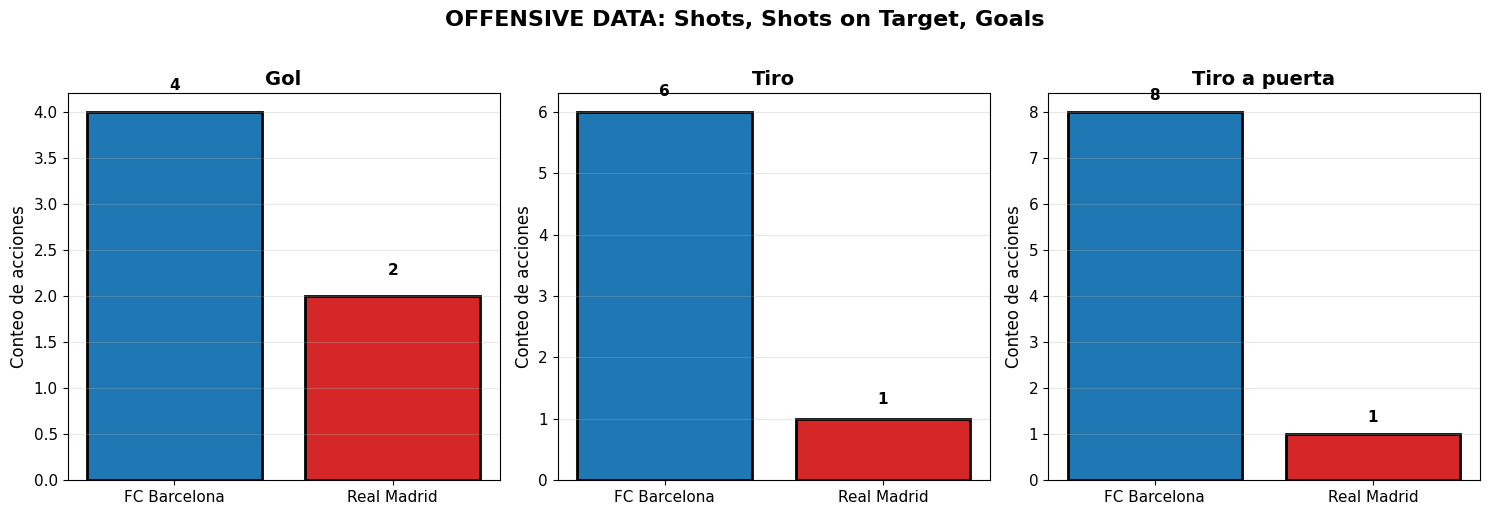

In [8]:
# OFFENSIVE DATA: Shots, shots on target, goals
offensive_actions_all = ["gol", "tiro", "tiro a puerta"]

# Filtrar solo las acciones que existen en teams_df
offensive_actions = [action for action in offensive_actions_all if action in teams_df.columns]

if len(offensive_actions) == 0:
    print("No offensive data available")
else:
    barcelona_counts = teams_df[teams_df['team'] == 'FC Barcelona'].iloc[0][offensive_actions]
    madrid_counts = teams_df[teams_df['team'] == 'Real Madrid'].iloc[0][offensive_actions]

    fig, axes = plt.subplots(1, len(offensive_actions), figsize=(5 * len(offensive_actions), 5))
    
    # Handle single action case (axes won't be array)
    if len(offensive_actions) == 1:
        axes = [axes]

    for idx, action in enumerate(offensive_actions):
        a_val = barcelona_counts[action]
        b_val = madrid_counts[action]
        
        axes[idx].bar(['FC Barcelona', 'Real Madrid'], [a_val, b_val], color=['tab:blue', 'tab:red'], edgecolor='black', linewidth=2)
        axes[idx].set_title(f'{action.capitalize()}', fontsize=14, fontweight='bold')
        axes[idx].set_ylabel('Conteo de acciones', fontsize=12)
        axes[idx].tick_params(axis='both', labelsize=11)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add values on bars
        axes[idx].text(0, a_val + 0.2, f'{int(a_val)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        axes[idx].text(1, b_val + 0.2, f'{int(b_val)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    fig.suptitle('OFFENSIVE DATA: Shots, Shots on Target, Goals', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


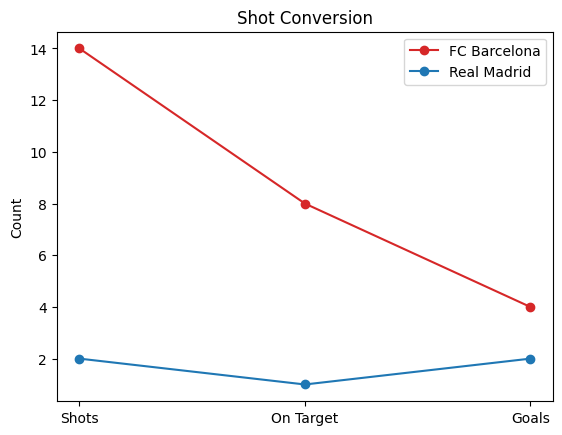

In [9]:
barcelona_shots_on_target = teams_df.loc[teams_df['team'] == 'FC Barcelona', 'tiro a puerta'].values[0]
barcelona_total_shots = teams_df.loc[teams_df['team'] == 'FC Barcelona', 'tiro'].values[0] + teams_df.loc[teams_df['team'] == 'FC Barcelona', 'tiro a puerta'].values[0]
barcelona_goals = teams_df.loc[teams_df['team'] == 'FC Barcelona', 'gol'].values[0]

madrid_shots_on_target = teams_df.loc[teams_df['team'] == 'Real Madrid', 'tiro a puerta'].values[0]
madrid_total_shots = teams_df.loc[teams_df['team'] == 'Real Madrid', 'tiro'].values[0] + teams_df.loc[teams_df['team'] == 'Real Madrid', 'tiro a puerta'].values[0]
madrid_goals = teams_df.loc[teams_df['team'] == 'Real Madrid', 'gol'].values[0]

fig, ax = plt.subplots()

levels = ["Shots", "On Target", "Goals"]

values = [barcelona_total_shots, barcelona_shots_on_target, barcelona_goals]
ax.plot(levels, values, marker='o', label='FC Barcelona', color='tab:red')
values = [madrid_total_shots, madrid_shots_on_target, madrid_goals]
ax.plot(levels, values, marker='o', label='Real Madrid', color='tab:blue')

ax.set_title("Shot Conversion")
ax.set_ylabel("Count")
ax.legend()
plt.show()

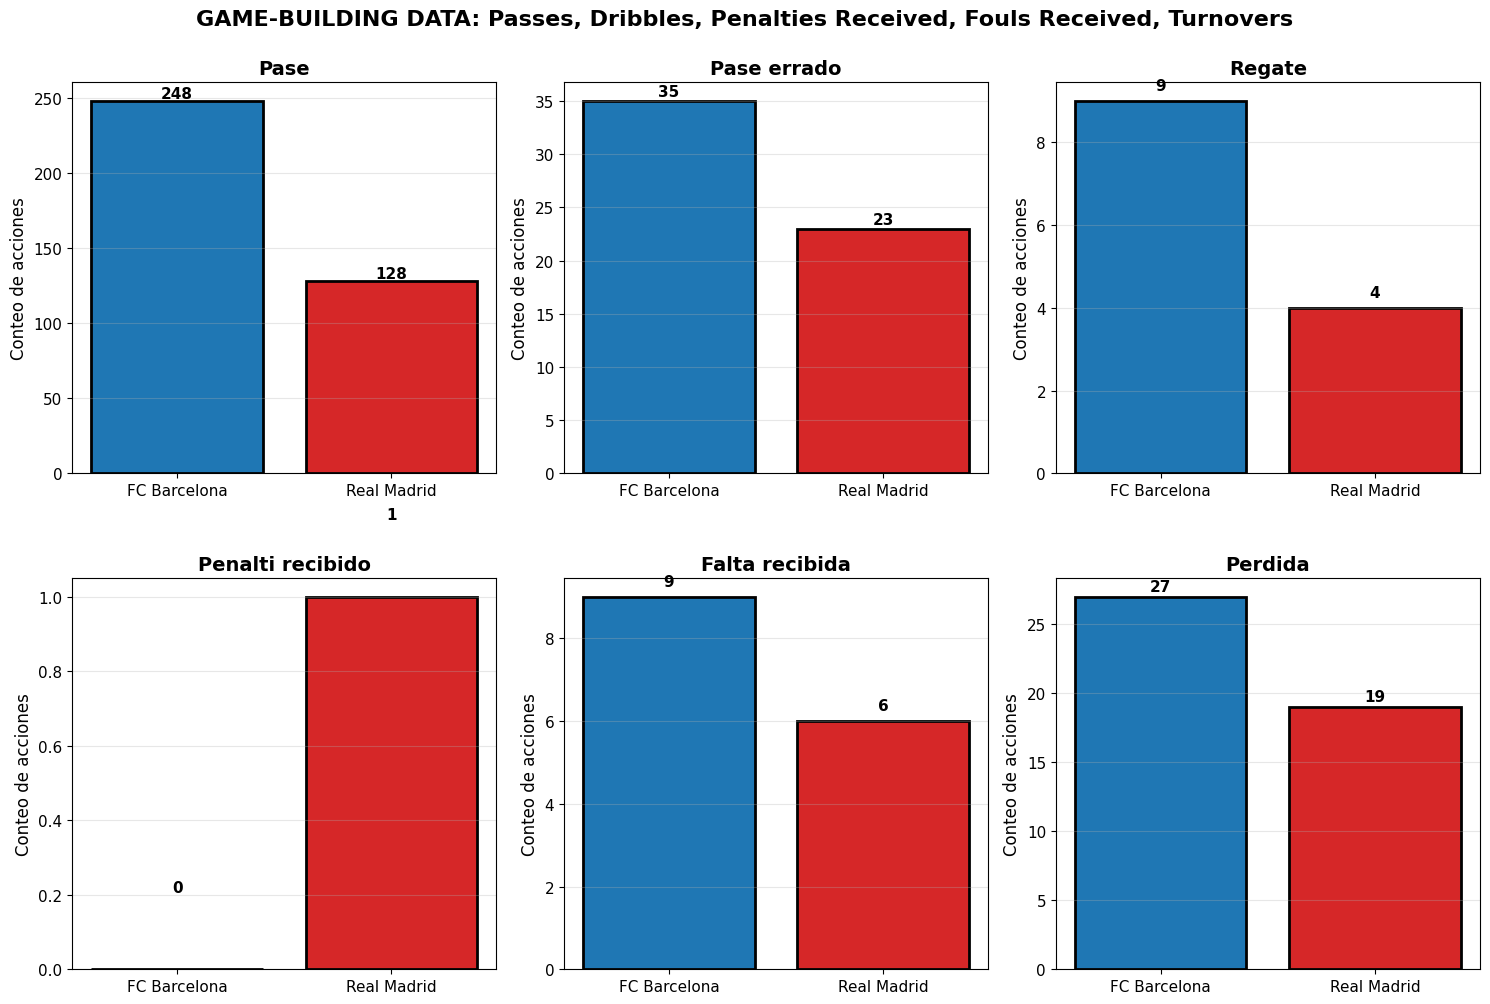

In [10]:
# GAME-BUILDING DATA: Passes, failed passes, dribbles, penalties received, fouls received, turnovers
gamebuilding_actions_all = ["pase", "pase errado", "regate", "penalti recibido", "falta recibida", "perdida"]

# Filtrar solo las acciones que existen en teams_df
gamebuilding_actions = [action for action in gamebuilding_actions_all if action in teams_df.columns]

if len(gamebuilding_actions) == 0:
    print("No game-building data available")
else:
    barcelona_counts = teams_df[teams_df['team'] == 'FC Barcelona'].iloc[0][gamebuilding_actions]
    madrid_counts = teams_df[teams_df['team'] == 'Real Madrid'].iloc[0][gamebuilding_actions]

    n_actions = len(gamebuilding_actions)
    n_cols = 3
    n_rows = (n_actions + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, action in enumerate(gamebuilding_actions):
        a_val = barcelona_counts[action]
        b_val = madrid_counts[action]
        
        axes[idx].bar(['FC Barcelona', 'Real Madrid'], [a_val, b_val], color=['tab:blue', 'tab:red'], edgecolor='black', linewidth=2)
        axes[idx].set_title(f'{action.capitalize()}', fontsize=14, fontweight='bold')
        axes[idx].set_ylabel('Conteo de acciones', fontsize=12)
        axes[idx].tick_params(axis='both', labelsize=11)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add values on bars
        axes[idx].text(0, a_val + 0.2, f'{int(a_val)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        axes[idx].text(1, b_val + 0.2, f'{int(b_val)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Ocultar subgráficas sobrantes
    for idx in range(n_actions, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('GAME-BUILDING DATA: Passes, Dribbles, Penalties Received, Fouls Received, Turnovers', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


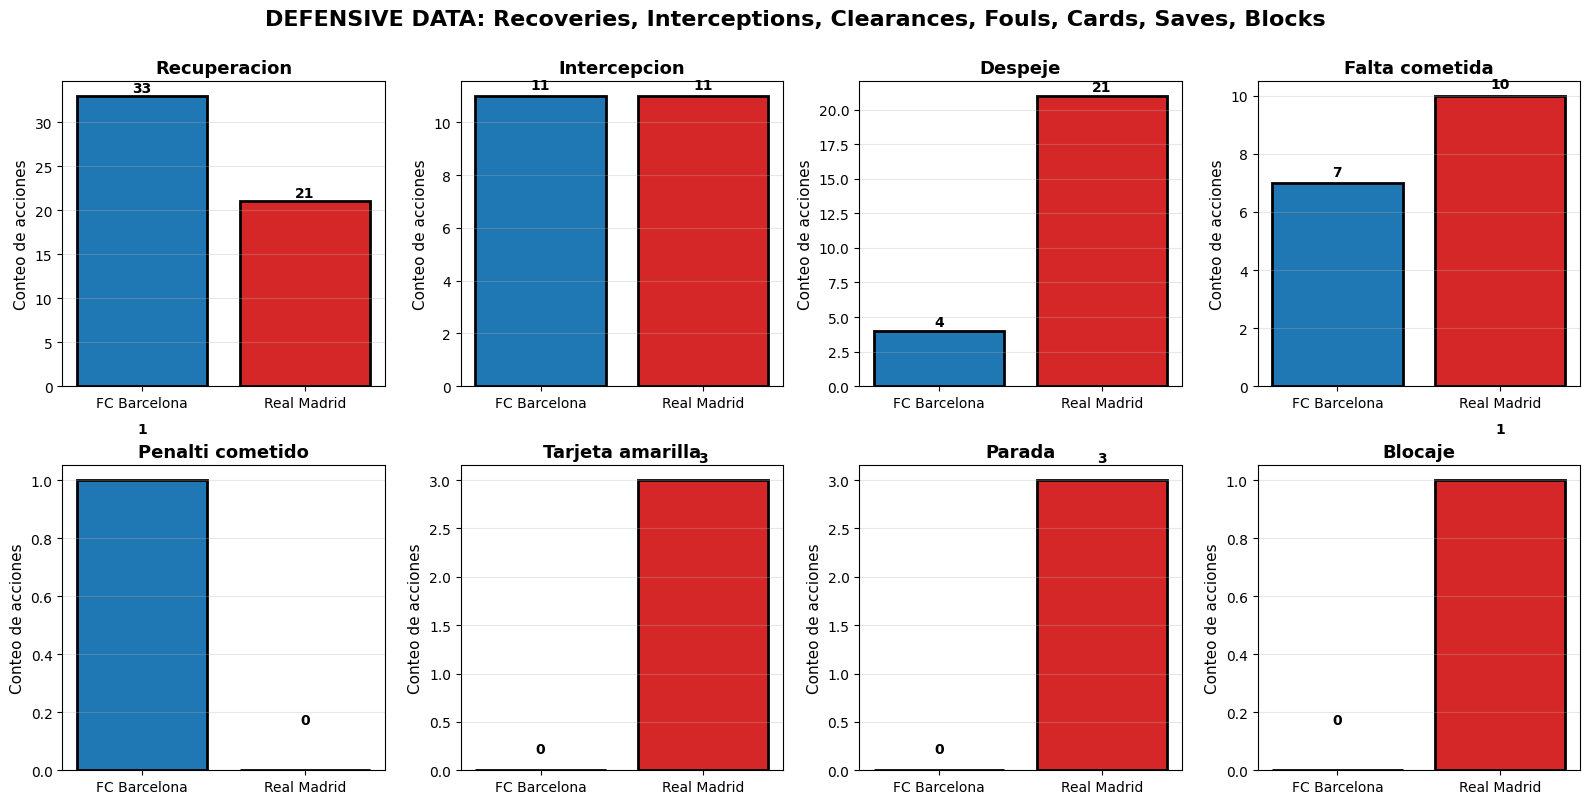

In [11]:
# DEFENSIVE DATA: Recoveries, interceptions, clearances, fouls committed, penalties committed, yellow cards, red cards, saves, blocks, penalties saved
defensive_actions_all = ["recuperacion", "intercepcion", "despeje", "falta cometida", "penalti cometido", "tarjeta amarilla", "tarjeta roja", "parada", "blocaje", "penalti parado"]

# Filtrar solo las acciones que existen en teams_df
defensive_actions = [action for action in defensive_actions_all if action in teams_df.columns]

if len(defensive_actions) == 0:
    print("No defensive data available")
else:
    barcelona_counts = teams_df[teams_df['team'] == 'FC Barcelona'].iloc[0][defensive_actions]
    madrid_counts = teams_df[teams_df['team'] == 'Real Madrid'].iloc[0][defensive_actions]

    n_actions = len(defensive_actions)
    n_cols = 4
    n_rows = (n_actions + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    for idx, action in enumerate(defensive_actions):
        a_val = barcelona_counts[action]
        b_val = madrid_counts[action]
        
        axes[idx].bar(['FC Barcelona', 'Real Madrid'], [a_val, b_val], color=['tab:blue', 'tab:red'], edgecolor='black', linewidth=2)
        axes[idx].set_title(f'{action.capitalize()}', fontsize=13, fontweight='bold')
        axes[idx].set_ylabel('Conteo de acciones', fontsize=11)
        axes[idx].tick_params(axis='both', labelsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add values on bars
        axes[idx].text(0, a_val + 0.15, f'{int(a_val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        axes[idx].text(1, b_val + 0.15, f'{int(b_val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Ocultar subgráficas sobrantes
    for idx in range(n_actions, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('DEFENSIVE DATA: Recoveries, Interceptions, Clearances, Fouls, Cards, Saves, Blocks', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


### Team Score metric


In this section, the goal is to create a metric that allows us to analyze which team is performing better on the field based on our statistics. This model assigns weights to three phases of the game: attack, defense, and build-up play, and calculates a score for each phase. From these three scores, a final rating is obtained.

In this model, balanced weights have been assigned, but depending on what we value more, we can influence the model’s behavior. For example, if the weight of the attacking phase is increased, the model will place more importance on teams with stronger attacking performance.

In [12]:
ATTACKING_WEIGHT = 0.35
DEFENDING_WEIGHT = 0.35
GAMEBUILDING_WEIGHT = 0.3

p75 = teams_df.quantile(0.75, numeric_only=True)

def get_team_score(team):
    return ATTACKING_WEIGHT * get_team_attacking_score(team) + DEFENDING_WEIGHT * get_team_defending_score(team) + GAMEBUILDING_WEIGHT * get_team_gamebuilding_score(team)

def get_team_attacking_score(team):
    shots = team.get("tiro", 0)
    shots_on_target = team.get("tiro a puerta", 0)
    goals = team.get("gol", 0)
    
    threat = min(safe_div(shots, p75["tiro"] * 1.3), 1)
    quality = min(safe_div(shots_on_target, p75["tiro a puerta"] * 1.3), 1)
    output = min(safe_div(goals, 5), 1)

    return min(1, threat * 0.2 + quality * 0.3 + output * 0.5) 

def get_team_defending_score(team):
    recoveries = team.get("recuperacion", 0)
    interceptions = team.get("intercepcion", 0)
    clearances = team.get("despeje", 0)
    fouls = team.get("falta cometida", 0)
    penalties_committed = team.get("penalti cometido", 0)
    yellow_cards = team.get("tarjeta amarilla", 0)
    red_cards = team.get("tarjeta roja", 0)
    saves = team.get("parada", 0)
    blocks = team.get("blocaje", 0)
    penalties_saved = team.get("penalti parado", 0)

    defensive_contribution = (
        min(safe_div(recoveries, p75["recuperacion"] * 1.3), 1) * 0.6 +
        min(safe_div(interceptions, p75["intercepcion"] * 1.3), 1) * 0.2 +
        min(safe_div(clearances, p75["despeje"] * 1.3), 1) * 0.2
    )

    goalkeeper_contribution = (
        min(safe_div(saves, p75["parada"] * 1.3), 1) * 0.3 +
        min(safe_div(blocks, p75["blocaje"] * 1.3), 1) * 0.4 +
        min(penalties_saved, 1) * 0.3
    )

    errors = (
        min(safe_div(fouls, p75["falta cometida"] * 1.3), 1) * 0.2 +
        min(penalties_committed, 1) * 0.3 +
        min(safe_div(yellow_cards, 3), 1) * 0.2 +
        min(red_cards, 1) * 0.3
    )

    return max(0, defensive_contribution * 0.4 + goalkeeper_contribution * 0.2 - errors * 0.4)

def get_team_gamebuilding_score(team):
    passes = team.get("pase", 0)
    failed_passes = team.get("pase errado", 0)
    dribbles = team.get("regate", 0)
    penalties_received = team.get("penalti recibido", 0)
    fouls_received = team.get("falta recibida", 0)
    turnovers = team.get("perdida", 0)

    control = max(0, min(passes / (p75["pase"] * 1.3), 1) * 0.6 - min(safe_div(failed_passes, p75["pase errado"] * 1.3), 1) * 0.2 - min(safe_div(turnovers, p75["perdida"] * 1.3), 1) * 0.2)
    creativity = min(safe_div(dribbles, p75["regate"] * 1.3), 1)
    advantage = (
        min(safe_div(fouls_received, p75["falta recibida"] * 1.3), 1) * 0.3 +
        min(penalties_received, 1) * 0.7
    )

    return control * 0.6 + creativity * 0.2 + advantage * 0.2

barcelona_team = teams_df[teams_df['team'] == 'FC Barcelona'].iloc[0]
madrid_team = teams_df[teams_df['team'] == 'Real Madrid'].iloc[0]

barcelona_score = get_team_score(barcelona_team)
madrid_score = get_team_score(madrid_team)

print("="*60)
print("MATCH PERFORMANCE REPORT")
print("="*60)

# --- SCORES GENERALES ---
print("\n📊 GLOBAL SCORE")
print(f"FC Barcelona: {barcelona_score:.2f}")
print(f"Real Madrid: {madrid_score:.2f}")

diff = barcelona_score - madrid_score
leader = "FC Barcelona" if diff > 0 else "Real Madrid"
print(f"Diferencia: {abs(diff):.2f} ({leader})")

dominance = barcelona_score / (barcelona_score + madrid_score)
print(f"Dominance FC Barcelona: {dominance:.2%}")

# --- ATTACKING ---
barca_att = get_team_attacking_score(barcelona_team)
madrid_att = get_team_attacking_score(madrid_team)

print("\n⚔️ ATTACKING")
print(f"FC Barcelona: {barca_att:.2f}")
print(f"Real Madrid: {madrid_att:.2f}")
print(f"Ventaja: {'FC Barcelona' if barca_att > madrid_att else 'Real Madrid'}")

# --- DEFENDING ---
barca_def = get_team_defending_score(barcelona_team)
madrid_def = get_team_defending_score(madrid_team)

print("\n🛡️ DEFENDING")
print(f"FC Barcelona: {barca_def:.2f}")
print(f"Real Madrid: {madrid_def:.2f}")
print(f"Ventaja: {'FC Barcelona' if barca_def > madrid_def else 'Real Madrid'}")

# --- GAMEBUILDING ---
barca_build = get_team_gamebuilding_score(barcelona_team)
madrid_build = get_team_gamebuilding_score(madrid_team)

print("\n🔄 GAME BUILDING")
print(f"FC Barcelona: {barca_build:.2f}")
print(f"Real Madrid: {madrid_build:.2f}")
print(f"Ventaja: {'FC Barcelona' if barca_build > madrid_build else 'Real Madrid'}")

MATCH PERFORMANCE REPORT

📊 GLOBAL SCORE
FC Barcelona: 0.45
Real Madrid: 0.27
Diferencia: 0.18 (FC Barcelona)
Dominance FC Barcelona: 62.75%

⚔️ ATTACKING
FC Barcelona: 0.89
Real Madrid: 0.27
Ventaja: FC Barcelona

🛡️ DEFENDING
FC Barcelona: 0.11
Real Madrid: 0.26
Ventaja: Real Madrid

🔄 GAME BUILDING
FC Barcelona: 0.34
Real Madrid: 0.28
Ventaja: FC Barcelona


In [13]:
match_section = len(df) / 4

teams_df_per_sections = [] 

actions = df["action"].unique()
teams = ["FC Barcelona", "Real Madrid"]

teams_df["team"] = teams

for i in range(4):
    section_df = df.iloc[int(i * match_section):int((i + 1) * match_section)]
    teams_df_section = pd.DataFrame()
    teams_df_section["team"] = teams
    for action in actions:
        teams_df_section[action] = 0

    teams_df_per_sections.append(teams_df_section)

for i in range(4):
    section_df = df.iloc[int(i * match_section):int((i + 1) * match_section)]
    counts = section_df.groupby(["player", "action"]).size()
    for (player, action), count in counts.items():
        if player == "rival":
            teams_df_per_sections[i].loc[teams_df_per_sections[i]["team"] == "Real Madrid", action] += count
        else:
            teams_df_per_sections[i].loc[teams_df_per_sections[i]["team"] == "FC Barcelona", action] += count

for i in range(4):
    print(f"\n📊 SECTION {i + 1}")
    barcelona_team = teams_df_per_sections[i][teams_df_per_sections[i]['team'] == 'FC Barcelona'].iloc[0]
    madrid_team = teams_df_per_sections[i][teams_df_per_sections[i]['team'] == 'Real Madrid'].iloc[0]

    barcelona_score = get_team_score(barcelona_team)
    madrid_score = get_team_score(madrid_team)

    print(f"FC Barcelona: {barcelona_score:.2f}")
    print(f"Real Madrid: {madrid_score:.2f}")

    diff = barcelona_score - madrid_score
    leader = "FC Barcelona" if diff > 0 else "Real Madrid"
    print(f"Diferencia: {abs(diff):.2f} ({leader})")


📊 SECTION 1
FC Barcelona: 0.04
Real Madrid: 0.18
Diferencia: 0.14 (Real Madrid)

📊 SECTION 2
FC Barcelona: 0.16
Real Madrid: 0.08
Diferencia: 0.08 (FC Barcelona)

📊 SECTION 3
FC Barcelona: 0.21
Real Madrid: 0.00
Diferencia: 0.21 (FC Barcelona)

📊 SECTION 4
FC Barcelona: 0.08
Real Madrid: 0.01
Diferencia: 0.07 (FC Barcelona)
